In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Load the cleaned reviews dataset

reviews_original = pd.read_csv(
    '../data/processed/reviews_clean.csv'
)

# Make copy of the cleaned data

reviews = reviews_original.copy()

reviews.head()

,review_id,order_id,customer_id,restaurant_id,review_rating,review_text,sentiment
0,REV_000001,ORD_004320,CUST_01005,REST_0069,5,The food was prepared really well. The deliver...,Positive
1,REV_000002,ORD_002354,CUST_00794,REST_0115,4,Very happy with the order. The food arrived ho...,Positive
2,REV_000003,ORD_004732,CUST_00476,REST_0060,3,The meal was fine. The delivery was okay.,Neutral
3,REV_000004,ORD_003302,CUST_01416,REST_0051,3,The food was okay overall. The meal was fine. ...,Neutral
4,REV_000005,ORD_002931,CUST_00384,REST_0059,4,Everything tasted great. The packaging was neat.,Positive


In [5]:
# Check the shape of the dataset

print('Shape:', reviews.shape)

# Display column names

print('\nColumns:')
print(reviews.columns.tolist())

# Display data types

print('\nData types:')
print(reviews.dtypes)

# Check missing values

print('\nMissing values:')
print(reviews.isnull().sum())

# Check duplicate rows

print('\nDuplicate rows:', reviews.duplicated().sum())

Shape: (7500, 7)

Columns:
['review_id', 'order_id', 'customer_id', 'restaurant_id', 'review_rating', 'review_text', 'sentiment']

Data types:
review_id          str
order_id           str
customer_id        str
restaurant_id      str
review_rating    int64
review_text        str
sentiment          str
dtype: object

Missing values:
review_id        0
order_id         0
customer_id      0
restaurant_id    0
review_rating    0
review_text      0
sentiment        0
dtype: int64

Duplicate rows: 0


In [6]:
# Inspect the review columns

reviews[
    [
        'review_rating',
        'review_text',
        'sentiment'
    ]
].head(10)

,review_rating,review_text,sentiment
0,5,The food was prepared really well. The deliver...,Positive
1,4,Very happy with the order. The food arrived ho...,Positive
2,3,The meal was fine. The delivery was okay.,Neutral
3,3,The food was okay overall. The meal was fine. ...,Neutral
4,4,Everything tasted great. The packaging was neat.,Positive
5,4,Loved the overall experience. Everything taste...,Positive
6,4,The meal was flavorful and satisfying. The del...,Positive
7,4,Really good experience.,Positive
8,4,Very happy with the order. The food was prepar...,Positive
9,4,Very happy with the order. Everything tasted g...,Positive


In [7]:
# Check sentiment distribution

print(
    reviews['sentiment'].value_counts()
)

print(
    reviews['sentiment'].value_counts(normalize=True) * 100
)

sentiment
Positive    6019
Neutral     1395
Negative      86
Name: count, dtype: int64
sentiment
Positive    80.253333
Neutral     18.600000
Negative     1.146667
Name: proportion, dtype: float64


The major issue isn't data quality — it's class imbalance.

You have only 86 negative reviews versus 6,019 positive reviews. This is going to matter later when we train the sentiment classifier.

For example, a model that predicts Positive for every review would already get about 80.25% accuracy, despite being completely useless for detecting negative customer experiences.

## Part 1 — Text Preprocessing

Natural Language Processing (NLP) deals with processing and analyzing human language using computational methods.

Text preprocessing converts raw review text into a cleaner and more consistent form that traditional machine learning algorithms can work with.

The main preprocessing steps used in this project are:

1. Lowercasing — converts all text to lowercase so that words such as "Food" and "food" are treated consistently.
2. Punctuation removal — removes characters such as `.`, `!`, and `?` when they are not useful for the selected model.
3. Tokenization — splits text into individual words or tokens.
4. Stop-word removal — removes very common words such as "the", "is", and "and" when they provide little useful information for the model.
5. Lemmatization — converts words to their base/dictionary form. For example, "running" may become "run".

These steps are particularly useful for traditional NLP approaches such as TF-IDF combined with machine learning models.

Note: Stop-word removal should be applied carefully because words such as "not" can be important for sentiment. We will consider this when building the sentiment pipeline.

In [8]:
# Import NLTK

import nltk

print('NLTK imported successfully.')

NLTK imported successfully.


In [9]:
# Download the NLTK resources required for preprocessing

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /home/nineleaps/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/nineleaps/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/nineleaps/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/nineleaps/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/nineleaps/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [10]:
# Display sample review text

reviews[['review_rating', 'review_text', 'sentiment']].sample(
    10,
    random_state=42
)

,review_rating,review_text,sentiment
970,5,The food was prepared really well. The driver ...,Positive
6279,4,Great food and service. The food was prepared ...,Positive
1859,4,Really good experience. The food quality was e...,Positive
6803,4,Everything tasted great. The packaging was neat.,Positive
6305,5,Really enjoyed the meal. The meal was flavorfu...,Positive
3039,5,The food quality was excellent. The delivery w...,Positive
7194,4,The portion size was good. Everything arrived ...,Positive
1446,4,The food arrived hot and fresh. Delivery was q...,Positive
5199,4,The meal was flavorful and satisfying. The pac...,Positive
6234,4,Really good experience. The food was fresh and...,Positive


In [11]:
# Calculate the number of characters in each review

reviews['review_length'] = reviews['review_text'].str.len()

reviews['review_length'].describe()

count    7500.000000
mean       66.267867
std        23.059305
min        23.000000
25%        53.000000
50%        68.000000
75%        86.000000
max       113.000000
Name: review_length, dtype: float64

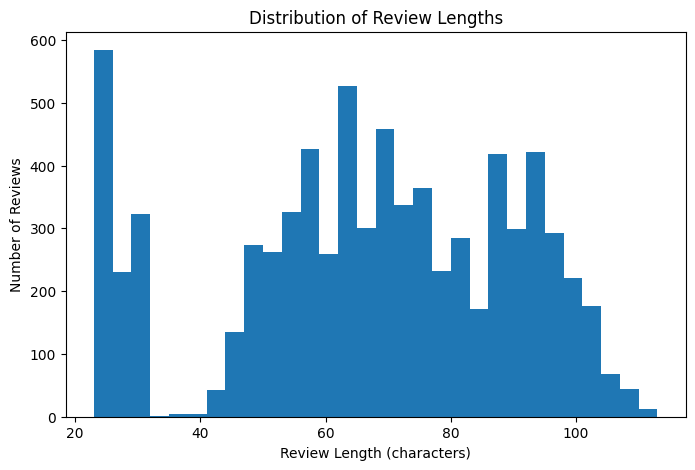

In [12]:
# Plot review length distribution

plt.figure(figsize=(8, 5))

plt.hist(
    reviews['review_length'],
    bins=30
)

plt.xlabel('Review Length (characters)')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Review Lengths')

plt.show()

### Review Length Interpretation

The review-length distribution helps us understand the nature of the text data before preprocessing.

Very short reviews may contain limited textual information, while longer reviews may contain multiple words or phrases that provide stronger signals for sentiment classification.

The distribution will also help identify whether the dataset consists mainly of short feedback statements or more detailed customer comments.

### Review Length Interpretation

The reviews contain moderate-length text, with an average length of approximately 66 characters and a median of 68 characters.

The shortest review contains 23 characters, while the longest contains 113 characters. Half of the reviews fall between 53 and 86 characters.

This indicates that the dataset mainly consists of short-to-moderate customer feedback rather than extremely short responses. Therefore, the reviews should contain sufficient textual information for traditional NLP techniques such as tokenization and TF-IDF.

No major text-length issue was identified at this stage.

## Text Preprocessing Pipeline

The raw review text will be transformed through several preprocessing steps:

Raw Text
↓
Lowercasing
↓
Punctuation Removal
↓
Tokenization
↓
Stop-word Removal
↓
Lemmatization
↓
Clean Text

### Key NLP Terms

**Token:**  
A single unit of text, usually a word. For example:

"great food and service"

becomes:

["great", "food", "and", "service"]

**Tokenization:**  
The process of splitting text into individual tokens.

**Stop Words:**  
Common words that often provide limited information for traditional NLP models, such as "the", "is", "and", and "a".

**Lemmatization:**  
Converting words to their base dictionary form while considering their meaning. For example, words such as "running" and "ran" can be converted toward their base form "run".

**TF-IDF:**  
Term Frequency-Inverse Document Frequency. It converts text into numerical features by giving higher importance to words that are relatively important to a document but less common across the entire collection of documents.

### Important Consideration

Stop-word removal can sometimes remove words that are important for sentiment. For example, "not" can completely change the meaning of a sentence.

Therefore, preprocessing choices should be evaluated based on their effect on the sentiment classification task rather than being treated as universally beneficial.

In [13]:
# Convert review text to lowercase

reviews['review_text_lower'] = (
    reviews['review_text']
    .str.lower()
)

reviews[
    ['review_text', 'review_text_lower']
].head()

,review_text,review_text_lower
0,The food was prepared really well. The deliver...,the food was prepared really well. the deliver...
1,Very happy with the order. The food arrived ho...,very happy with the order. the food arrived ho...
2,The meal was fine. The delivery was okay.,the meal was fine. the delivery was okay.
3,The food was okay overall. The meal was fine. ...,the food was okay overall. the meal was fine. ...
4,Everything tasted great. The packaging was neat.,everything tasted great. the packaging was neat.


### Step 2 — Punctuation Removal

Punctuation marks such as `.`, `,`, `!`, and `?` are removed from the review text for the traditional TF-IDF pipeline.

For example:

`"Great food, and quick delivery!"`

becomes:

`"great food and quick delivery"`

Removing punctuation reduces unnecessary variation in the text representation.

However, punctuation can sometimes carry sentiment information, especially repeated exclamation marks. Since this project will also compare the traditional NLP approach with VADER, we will preserve the original `review_text` column and only create cleaned versions for the traditional ML pipeline.

In [14]:
# Import the regular expression library

import re


# Remove punctuation from the lowercased review text

reviews['review_text_no_punctuation'] = (
    reviews['review_text_lower']
    .apply(
        lambda text: re.sub(
            r'[^\w\s]',
            '',
            text
        )
    )
)


# Compare the original and cleaned text

reviews[
    [
        'review_text',
        'review_text_no_punctuation'
    ]
].head()

,review_text,review_text_no_punctuation
0,The food was prepared really well. The deliver...,the food was prepared really well the delivery...
1,Very happy with the order. The food arrived ho...,very happy with the order the food arrived hot...
2,The meal was fine. The delivery was okay.,the meal was fine the delivery was okay
3,The food was okay overall. The meal was fine. ...,the food was okay overall the meal was fine de...
4,Everything tasted great. The packaging was neat.,everything tasted great the packaging was neat


In [15]:
# Import NLTK tokenizer

from nltk.tokenize import word_tokenize


# Tokenize each cleaned review

reviews['tokens'] = (
    reviews['review_text_no_punctuation'].apply(word_tokenize)
)


# View the result

reviews[
    ['review_text_no_punctuation', 'tokens']
].head()

,review_text_no_punctuation,tokens
0,the food was prepared really well the delivery...,"[the, food, was, prepared, really, well, the, ..."
1,very happy with the order the food arrived hot...,"[very, happy, with, the, order, the, food, arr..."
2,the meal was fine the delivery was okay,"[the, meal, was, fine, the, delivery, was, okay]"
3,the food was okay overall the meal was fine de...,"[the, food, was, okay, overall, the, meal, was..."
4,everything tasted great the packaging was neat,"[everything, tasted, great, the, packaging, wa..."


### Step 3 — Tokenization

Tokenization splits a sentence into individual words (tokens).

Example:
"great food and quick delivery"

→ ["great", "food", "and", "quick", "delivery"]

In [16]:
# Import NLTK tokenizer

from nltk.tokenize import word_tokenize


# Tokenize each cleaned review

reviews['tokens'] = (
    reviews['review_text_no_punctuation']
    .apply(word_tokenize)
)


# View the result

reviews[
    ['review_text_no_punctuation', 'tokens']
].head()

,review_text_no_punctuation,tokens
0,the food was prepared really well the delivery...,"[the, food, was, prepared, really, well, the, ..."
1,very happy with the order the food arrived hot...,"[very, happy, with, the, order, the, food, arr..."
2,the meal was fine the delivery was okay,"[the, meal, was, fine, the, delivery, was, okay]"
3,the food was okay overall the meal was fine de...,"[the, food, was, okay, overall, the, meal, was..."
4,everything tasted great the packaging was neat,"[everything, tasted, great, the, packaging, wa..."


### Step 4 — Stop-word Removal

Stop words are very common words such as "the", "is", "and", and "a".

Removing them can reduce noise and the number of features used by traditional NLP models.

In [17]:
# Import the English stop-word list

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))


# Remove stop words from the tokens

reviews['tokens_no_stopwords'] = (
    reviews['tokens']
    .apply(
        lambda tokens: [
            word
            for word in tokens
            if word not in stop_words
        ]
    )
)


# View the result

reviews[
    ['tokens', 'tokens_no_stopwords']
].head()

,tokens,tokens_no_stopwords
0,"[the, food, was, prepared, really, well, the, ...","[food, prepared, really, well, delivery, smooth]"
1,"[very, happy, with, the, order, the, food, arr...","[happy, order, food, arrived, hot, fresh, orde..."
2,"[the, meal, was, fine, the, delivery, was, okay]","[meal, fine, delivery, okay]"
3,"[the, food, was, okay, overall, the, meal, was...","[food, okay, overall, meal, fine, delivery, ne..."
4,"[everything, tasted, great, the, packaging, wa...","[everything, tasted, great, packaging, neat]"


### Step 5 — Lemmatization

Lemmatization converts words to their base dictionary form.

Example:

"running" → "run"

This helps treat different forms of the same word as a common feature.

In [18]:
# Import WordNet lemmatizer

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()


# Lemmatize each token

reviews['lemmatized_tokens'] = (
    reviews['tokens_no_stopwords']
    .apply(
        lambda tokens: [
            lemmatizer.lemmatize(word)
            for word in tokens
        ]
    )
)


# View the result

reviews[
    ['tokens_no_stopwords', 'lemmatized_tokens']
].head()

,tokens_no_stopwords,lemmatized_tokens
0,"[food, prepared, really, well, delivery, smooth]","[food, prepared, really, well, delivery, smooth]"
1,"[happy, order, food, arrived, hot, fresh, orde...","[happy, order, food, arrived, hot, fresh, orde..."
2,"[meal, fine, delivery, okay]","[meal, fine, delivery, okay]"
3,"[food, okay, overall, meal, fine, delivery, ne...","[food, okay, overall, meal, fine, delivery, ne..."
4,"[everything, tasted, great, packaging, neat]","[everything, tasted, great, packaging, neat]"


### Step 6 — Create Final Clean Text

The processed tokens are joined back into a single text string.

This creates the final text representation that will be passed to TF-IDF.

In [19]:
# Convert lemmatized tokens back into text

reviews['clean_text'] = (
    reviews['lemmatized_tokens']
    .apply(lambda tokens: ' '.join(tokens))
)


# Compare original and cleaned text

reviews[
    ['review_text', 'clean_text', 'sentiment']
].head(10)

,review_text,clean_text,sentiment
0,The food was prepared really well. The deliver...,food prepared really well delivery smooth,Positive
1,Very happy with the order. The food arrived ho...,happy order food arrived hot fresh order arriv...,Positive
2,The meal was fine. The delivery was okay.,meal fine delivery okay,Neutral
3,The food was okay overall. The meal was fine. ...,food okay overall meal fine delivery neither f...,Neutral
4,Everything tasted great. The packaging was neat.,everything tasted great packaging neat,Positive
5,Loved the overall experience. Everything taste...,loved overall experience everything tasted gre...,Positive
6,The meal was flavorful and satisfying. The del...,meal flavorful satisfying delivery smooth,Positive
7,Really good experience.,really good experience,Positive
8,Very happy with the order. The food was prepar...,happy order food prepared really well delivery...,Positive
9,Very happy with the order. Everything tasted g...,happy order everything tasted great order arri...,Positive


In [20]:
# Check whether preprocessing created any empty reviews

empty_reviews = (
    reviews['clean_text']
    .str.strip()
    .eq('')
    .sum()
)

print('Empty cleaned reviews:', empty_reviews)

Empty cleaned reviews: 0


In [21]:
# Display the review columns used during preprocessing

reviews[
    [
        'review_text',
        'clean_text',
        'review_rating',
        'sentiment'
    ]
].head()

,review_text,clean_text,review_rating,sentiment
0,The food was prepared really well. The deliver...,food prepared really well delivery smooth,5,Positive
1,Very happy with the order. The food arrived ho...,happy order food arrived hot fresh order arriv...,4,Positive
2,The meal was fine. The delivery was okay.,meal fine delivery okay,3,Neutral
3,The food was okay overall. The meal was fine. ...,food okay overall meal fine delivery neither f...,3,Neutral
4,Everything tasted great. The packaging was neat.,everything tasted great packaging neat,4,Positive


In [22]:
# Save the cleaned review dataset

reviews.to_csv(
    '../data/processed/reviews_nlp_cleaned.csv',
    index=False
)

print('Cleaned NLP dataset saved successfully.')

Cleaned NLP dataset saved successfully.


review_text
     ↓
VADER
     ↓
Keeps original punctuation/context


clean_text
     ↓
TF-IDF
     ↓
Traditional ML model

## Part 2 — TF-IDF

TF-IDF converts text into numerical features that machine learning models can use.

- TF (Term Frequency): how often a word appears in a review.
- IDF (Inverse Document Frequency): gives lower importance to words that appear in many reviews.
- TF-IDF: combines both to give higher weight to words that are more specific to a review.

We will use both unigrams and bigrams to capture individual words and short phrases.

In [23]:
# Import TF-IDF vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer


# Create the TF-IDF vectorizer

tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2
)


# Transform the cleaned reviews into numerical features

X_tfidf = tfidf.fit_transform(
    reviews['clean_text']
)


# Check the resulting matrix

print('TF-IDF matrix shape:', X_tfidf.shape)

TF-IDF matrix shape: (7500, 305)


max_features=3000
→ Keep at most 3,000 text features.

ngram_range=(1, 2)
→ Use single words AND two-word phrases.

min_df=2
→ Ignore terms appearing in fewer than 2 reviews.

In [24]:
# Get the TF-IDF feature names

feature_names = tfidf.get_feature_names_out()


# Calculate average TF-IDF score for each feature

mean_tfidf = X_tfidf.mean(axis=0).A1


# Create a DataFrame of feature importance

tfidf_features = pd.DataFrame({
    'feature': feature_names,
    'mean_tfidf': mean_tfidf
})


# Sort by TF-IDF score

tfidf_features = (
    tfidf_features
    .sort_values(
        'mean_tfidf',
        ascending=False
    )
)


# Display the top 20 features

tfidf_features.head()

,feature,mean_tfidf
116,food,0.076257
192,order,0.067801
10,arrived,0.057875
54,delivery,0.057585
127,fresh,0.055112


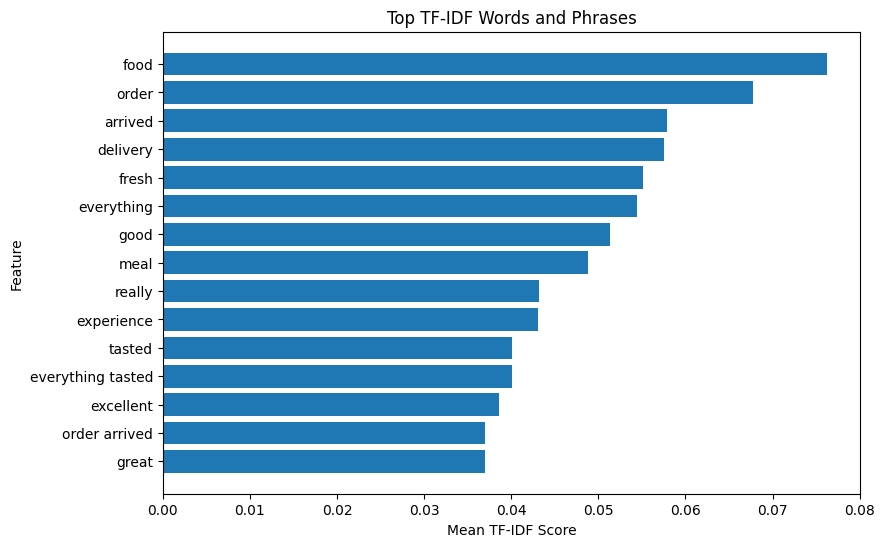

In [25]:
# Select the top 15 TF-IDF features

top_features = (
    tfidf_features
    .head(15)
    .sort_values('mean_tfidf')
)


# Plot the results

plt.figure(figsize=(9, 6))

plt.barh(
    top_features['feature'],
    top_features['mean_tfidf']
)

plt.xlabel('Mean TF-IDF Score')
plt.ylabel('Feature')
plt.title('Top TF-IDF Words and Phrases')

plt.show()

### TF-IDF Interpretation

Features with higher mean TF-IDF scores are relatively more informative across the review collection.

Both individual words and two-word phrases are included, allowing the analysis to capture common sentiment-related terms and phrases.

### TF-IDF Findings

The highest-weighted features are mainly related to food quality, freshness, order condition, and delivery.

Important phrases such as "everything tasted", "order arrived", and "food quality" provide additional context beyond individual words.

These features will be used as inputs for the sentiment classification models.

## Part 3 — Sentiment Classification

We will use the TF-IDF features to predict the review sentiment.

Target:

Positive / Neutral / Negative

Because the classes are highly imbalanced, accuracy alone will not be sufficient for evaluating the model. We will also use precision, recall, F1-score, and a confusion matrix.

In [26]:
# Import train-test split

from sklearn.model_selection import train_test_split


# Define the target variable

y = reviews['sentiment']


# Split the TF-IDF features into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Check the resulting sizes

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 6000
Testing samples: 1500


### Naive Bayes

Naive Bayes is a probabilistic classification algorithm.

It estimates the probability that a review belongs to each sentiment class based on the words/features present in the review.

Multinomial Naive Bayes is commonly used for text classification because it works well with high-dimensional text features such as TF-IDF.

In [27]:
# Import the Naive Bayes classifier

from sklearn.naive_bayes import MultinomialNB


# Create the model

nb_model = MultinomialNB()


# Train the model

nb_model.fit(
    X_train,
    y_train
)


# Generate predictions

nb_predictions = nb_model.predict(
    X_test
)


# Display sample predictions

print(nb_predictions[:10])

['Positive' 'Neutral' 'Positive' 'Neutral' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive']


### Model Evaluation

We will evaluate the classifier using:

- Accuracy — overall percentage of correct predictions.
- Precision — how many predicted instances of a class were actually that class.
- Recall — how many actual instances of a class were correctly identified.
- F1-score — balance between precision and recall.

Because the Negative class is highly underrepresented, F1-score, precision, and recall are especially important.

In [28]:
# Import classification metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


# Calculate evaluation metrics

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

nb_precision = precision_score(
    y_test,
    nb_predictions,
    average='weighted',
    zero_division=0
)

nb_recall = recall_score(
    y_test,
    nb_predictions,
    average='weighted',
    zero_division=0
)

nb_f1 = f1_score(
    y_test,
    nb_predictions,
    average='weighted',
    zero_division=0
)


# Display metrics

print('Naive Bayes Accuracy:', round(nb_accuracy, 4))
print('Naive Bayes Precision:', round(nb_precision, 4))
print('Naive Bayes Recall:', round(nb_recall, 4))
print('Naive Bayes F1-score:', round(nb_f1, 4))


# Display class-level performance

print('\nClassification Report:')
print(
    classification_report(
        y_test,
        nb_predictions,
        zero_division=0
    )
)

Naive Bayes Accuracy: 0.9993
Naive Bayes Precision: 0.9993
Naive Bayes Recall: 0.9993
Naive Bayes F1-score: 0.9993

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.94      0.97        17
     Neutral       1.00      1.00      1.00       279
    Positive       1.00      1.00      1.00      1204

    accuracy                           1.00      1500
   macro avg       1.00      0.98      0.99      1500
weighted avg       1.00      1.00      1.00      1500



### Confusion Matrix

A confusion matrix shows how many observations were correctly and incorrectly classified for each sentiment class.

It helps identify which sentiment classes the model struggles to distinguish.

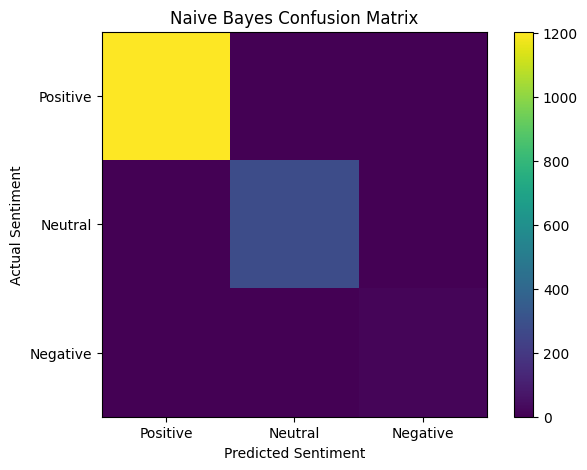

In [29]:
# Import confusion matrix

from sklearn.metrics import confusion_matrix


# Calculate confusion matrix

nb_cm = confusion_matrix(
    y_test,
    nb_predictions,
    labels=[
        'Positive',
        'Neutral',
        'Negative'
    ]
)


# Plot confusion matrix

plt.figure(figsize=(7, 5))

plt.imshow(nb_cm)

plt.xticks(
    range(3),
    ['Positive', 'Neutral', 'Negative']
)

plt.yticks(
    range(3),
    ['Positive', 'Neutral', 'Negative']
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Naive Bayes Confusion Matrix')

plt.colorbar()

plt.show()

### Confusion Matrix Interpretation

The confusion matrix contains more observations for the Positive class because the dataset is highly imbalanced.

The color intensity represents the number of observations in each cell, not model performance.

Naive Bayes correctly classified almost all reviews across the three sentiment classes, with only one Negative review misclassified in the test set.

Class-level metrics are therefore used alongside the confusion matrix to evaluate model performance.

## Support Vector Machine

SVM is a supervised classification algorithm that finds a decision boundary that best separates different classes.

For text classification, SVM often performs well with high-dimensional TF-IDF features.

We will compare its performance with Naive Bayes using the same training and testing data.

In [30]:
# Import the SVM classifier

from sklearn.svm import LinearSVC


# Create the SVM model

svm_model = LinearSVC(
    random_state=42
)


# Train the model

svm_model.fit(
    X_train,
    y_train
)


# Generate predictions

svm_predictions = svm_model.predict(
    X_test
)


# Display sample predictions

print(svm_predictions[:10])

['Positive' 'Neutral' 'Positive' 'Neutral' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive']


In [31]:
# Calculate SVM evaluation metrics

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

svm_precision = precision_score(
    y_test,
    svm_predictions,
    average='weighted',
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    svm_predictions,
    average='weighted',
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    svm_predictions,
    average='weighted',
    zero_division=0
)


# Display overall metrics

print('SVM Accuracy:', round(svm_accuracy, 4))
print('SVM Precision:', round(svm_precision, 4))
print('SVM Recall:', round(svm_recall, 4))
print('SVM F1-score:', round(svm_f1, 4))


# Display class-level performance

print('\nClassification Report:')
print(
    classification_report(
        y_test,
        svm_predictions,
        zero_division=0
    )
)

SVM Accuracy: 0.9987
SVM Precision: 0.9987
SVM Recall: 0.9987
SVM F1-score: 0.9986

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.88      0.94        17
     Neutral       1.00      1.00      1.00       279
    Positive       1.00      1.00      1.00      1204

    accuracy                           1.00      1500
   macro avg       1.00      0.96      0.98      1500
weighted avg       1.00      1.00      1.00      1500



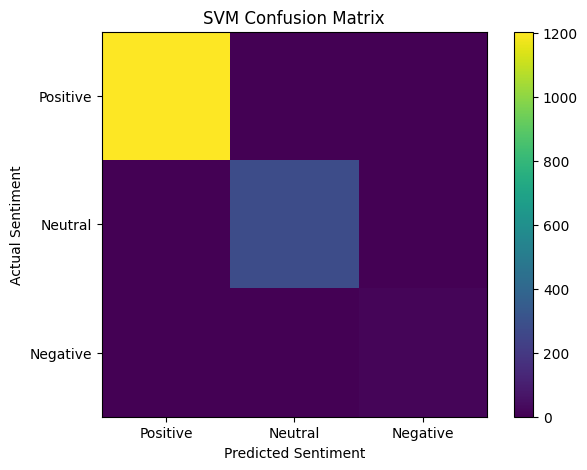

In [32]:
# Calculate the SVM confusion matrix

svm_cm = confusion_matrix(
    y_test,
    svm_predictions,
    labels=[
        'Positive',
        'Neutral',
        'Negative'
    ]
)


# Plot the confusion matrix

plt.figure(figsize=(7, 5))

plt.imshow(svm_cm)

plt.xticks(
    range(3),
    ['Positive', 'Neutral', 'Negative']
)

plt.yticks(
    range(3),
    ['Positive', 'Neutral', 'Negative']
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('SVM Confusion Matrix')

plt.colorbar()

plt.show()

In [33]:
# Create a model comparison table

sentiment_model_comparison = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'SVM'
    ],
    'Accuracy': [
        nb_accuracy,
        svm_accuracy
    ],
    'Precision': [
        nb_precision,
        svm_precision
    ],
    'Recall': [
        nb_recall,
        svm_recall
    ],
    'F1-score': [
        nb_f1,
        svm_f1
    ]
})


# Round the metrics

sentiment_model_comparison = sentiment_model_comparison.round(4)


# Display comparison

sentiment_model_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,0.9993,0.9993,0.9993,0.9993
1,SVM,0.9987,0.9987,0.9987,0.9986


### Model Comparison

Naive Bayes slightly outperformed SVM across the overall evaluation metrics.

The most important difference is the Negative class. Naive Bayes achieved 0.94 recall compared with 0.88 for SVM, meaning it identified more actual negative reviews.

Since identifying dissatisfied customers is an important business objective, Naive Bayes is selected as the preferred traditional sentiment classification model.

The extremely high scores should be interpreted carefully because the synthetic review dataset contains highly repetitive and clearly worded sentiment patterns.

In [34]:
# Import VADER

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


# Create the VADER analyzer

vader = SentimentIntensityAnalyzer()

In [35]:
# Calculate VADER sentiment scores

reviews['vader_compound'] = reviews['review_text'].apply(
    lambda text: vader.polarity_scores(text)['compound']
)


# Convert VADER scores into sentiment classes

def classify_vader(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'


reviews['vader_sentiment'] = reviews['vader_compound'].apply(
    classify_vader
)


# Display the results

reviews[
    [
        'review_text',
        'sentiment',
        'vader_compound',
        'vader_sentiment'
    ]
].head(10)

,review_text,sentiment,vader_compound,vader_sentiment
0,The food was prepared really well. The deliver...,Positive,0.5095,Positive
1,Very happy with the order. The food arrived ho...,Positive,0.7425,Positive
2,The meal was fine. The delivery was okay.,Neutral,0.4019,Positive
3,The food was okay overall. The meal was fine. ...,Neutral,0.4019,Positive
4,Everything tasted great. The packaging was neat.,Positive,0.7964,Positive
5,Loved the overall experience. Everything taste...,Positive,0.8402,Positive
6,The meal was flavorful and satisfying. The del...,Positive,0.4588,Positive
7,Really good experience.,Positive,0.4927,Positive
8,Very happy with the order. The food was prepar...,Positive,0.8067,Positive
9,Very happy with the order. Everything tasted g...,Positive,0.8439,Positive


### VADER Evaluation

VADER assigns sentiment scores using a predefined sentiment lexicon and rule-based approach rather than learning from the training data.

We compare its predictions against the existing sentiment labels using the same classification metrics used for Naive Bayes and SVM.

In [36]:
# Calculate VADER evaluation metrics

vader_accuracy = accuracy_score(
    reviews['sentiment'],
    reviews['vader_sentiment']
)

vader_precision = precision_score(
    reviews['sentiment'],
    reviews['vader_sentiment'],
    average='weighted',
    zero_division=0
)

vader_recall = recall_score(
    reviews['sentiment'],
    reviews['vader_sentiment'],
    average='weighted',
    zero_division=0
)

vader_f1 = f1_score(
    reviews['sentiment'],
    reviews['vader_sentiment'],
    average='weighted',
    zero_division=0
)


# Display overall metrics

print('VADER Accuracy:', round(vader_accuracy, 4))
print('VADER Precision:', round(vader_precision, 4))
print('VADER Recall:', round(vader_recall, 4))
print('VADER F1-score:', round(vader_f1, 4))


# Display class-level performance

print('\nClassification Report:')

print(
    classification_report(
        reviews['sentiment'],
        reviews['vader_sentiment'],
        zero_division=0
    )
)

VADER Accuracy: 0.8632
VADER Precision: 0.8912
VADER Recall: 0.8632
VADER F1-score: 0.8358

Classification Report:
              precision    recall  f1-score   support

    Negative       0.26      0.78      0.39        86
     Neutral       0.98      0.28      0.43      1395
    Positive       0.88      1.00      0.94      6019

    accuracy                           0.86      7500
   macro avg       0.71      0.69      0.59      7500
weighted avg       0.89      0.86      0.84      7500



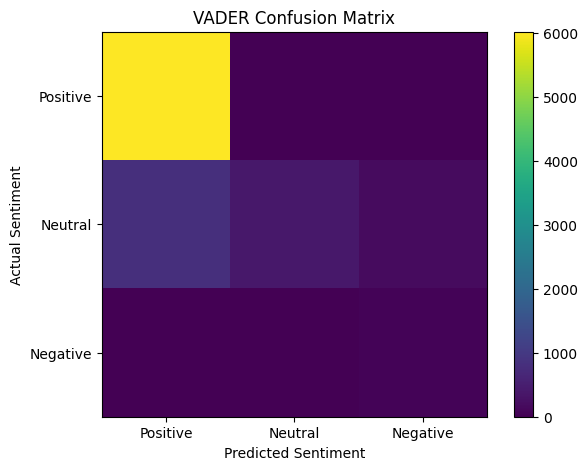

In [37]:
# Create VADER confusion matrix

vader_cm = confusion_matrix(
    reviews['sentiment'],
    reviews['vader_sentiment'],
    labels=[
        'Positive',
        'Neutral',
        'Negative'
    ]
)


# Plot confusion matrix

plt.figure(figsize=(7, 5))

plt.imshow(vader_cm)

plt.xticks(
    range(3),
    ['Positive', 'Neutral', 'Negative']
)

plt.yticks(
    range(3),
    ['Positive', 'Neutral', 'Negative']
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')

plt.title('VADER Confusion Matrix')

plt.colorbar()

plt.show()

In [38]:
# Add VADER to the model comparison

sentiment_model_comparison = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'SVM',
        'VADER'
    ],
    'Accuracy': [
        nb_accuracy,
        svm_accuracy,
        vader_accuracy
    ],
    'Precision': [
        nb_precision,
        svm_precision,
        vader_precision
    ],
    'Recall': [
        nb_recall,
        svm_recall,
        vader_recall
    ],
    'F1-score': [
        nb_f1,
        svm_f1,
        vader_f1
    ]
})


# Round the metrics

sentiment_model_comparison = sentiment_model_comparison.round(4)


# Display the comparison

sentiment_model_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,0.9993,0.9993,0.9993,0.9993
1,SVM,0.9987,0.9987,0.9987,0.9986
2,VADER,0.8632,0.8912,0.8632,0.8358


### VADER vs Traditional ML

VADER achieved 86.32% accuracy and an F1-score of 83.58%, which was substantially lower than Naive Bayes and SVM.

VADER performed particularly poorly in identifying Neutral reviews, achieving only 0.28 recall.

Naive Bayes performed best overall, with an F1-score of 99.93%, followed closely by SVM at 99.86%.

The difference is expected because Naive Bayes and SVM learn sentiment patterns from the dataset, while VADER uses a predefined sentiment lexicon and rule-based scoring.

Therefore, Naive Bayes is selected as the preferred sentiment classification model for this dataset.

In [40]:
# Filter negative reviews

negative_reviews = reviews[
    reviews['sentiment'] == 'Negative'
].copy()


# Display the negative review text

negative_reviews[
    [
        'review_rating',
        'review_text'
    ]
].head(20)

,review_rating,review_text
12,2,The order could have been much better.
17,2,The order could have been much better. The foo...
73,2,I was disappointed with the order. The meal di...
74,2,The order could have been much better. The foo...
156,2,The meal did not taste fresh. The order took m...
230,2,I was not satisfied with the order.
371,2,The food quality needs improvement. The order ...
611,2,The overall experience was disappointing.
819,2,I was not satisfied with the order.
900,2,The food arrived cold. The delivery experience...


In [42]:
# Import TF-IDF Vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer


# Create the TF-IDF vectorizer

tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2)
)


# Fit the vectorizer on the complete review dataset

tfidf_vectorizer.fit(
    reviews['review_text']
)

,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\

In [43]:
# Create a TF-IDF matrix using only negative reviews

negative_tfidf = tfidf_vectorizer.transform(
    negative_reviews['review_text']
)


# Calculate average TF-IDF for each word

negative_tfidf_mean = np.asarray(
    negative_tfidf.mean(axis=0)
).flatten()


# Create a table of negative-review features

negative_features = pd.DataFrame({
    'feature': tfidf_vectorizer.get_feature_names_out(),
    'mean_tfidf': negative_tfidf_mean
})


# Sort by importance

negative_features = negative_features.sort_values(
    'mean_tfidf',
    ascending=False
)


# Display top negative-review features

negative_features.head(15)

,feature,mean_tfidf
64,disappointing,0.078623
217,poor,0.071433
151,happy experience,0.070841
91,experience,0.068448
184,order,0.062923
171,meal did,0.060771
279,taste fresh,0.060771
61,did taste,0.060771
60,did,0.060771
97,experience poor,0.060304


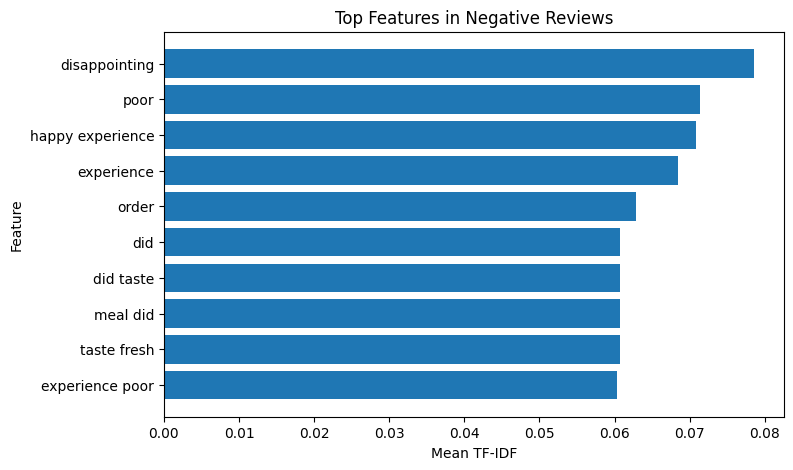

In [44]:
# Select the top 10 negative-review features

top_negative_features = negative_features.head(10).sort_values(
    'mean_tfidf'
)


# Create the plot

plt.figure(figsize=(8, 5))

plt.barh(
    top_negative_features['feature'],
    top_negative_features['mean_tfidf']
)

plt.xlabel('Mean TF-IDF')
plt.ylabel('Feature')
plt.title('Top Features in Negative Reviews')

plt.show()

### Negative Review Themes

The most prominent terms in negative reviews indicate the main areas of customer dissatisfaction.

These themes can help identify operational areas that may require improvement, such as food quality, delivery delays, freshness, or order handling.

Naive Bayes achieved the highest overall performance with an F1-score of 99.93%, compared with 99.86% for SVM and 83.58% for VADER.